In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

In [13]:
#Loading the data
dataframe=pd.read_csv("life_expectancy.csv")


In [14]:
# EDA -Performing Explonatory Data Analysis before datacleaning
print(dataframe.shape)

(2848, 18)


In [15]:
print(dataframe.describe())

              Year    Population  Hepatitis B        Measles        Polio  \
count  2848.000000  2.204000e+03  2306.000000    2848.000000  2829.000000   
mean   2007.500000  1.283457e+07    81.076756    2083.082163    82.682220   
std       4.610582  6.196094e+07    25.019068   10249.107207    23.434954   
min    2000.000000  3.400000e+01     1.000000       0.000000     3.000000   
25%    2003.750000  1.967585e+05    77.000000       0.000000    78.000000   
50%    2007.500000  1.391756e+06    92.000000      16.000000    93.000000   
75%    2011.250000  7.438947e+06    97.000000     336.750000    97.000000   
max    2015.000000  1.293859e+09    99.000000  212183.000000    99.000000   

        Diphtheria     HIV/AIDS  infant deaths  under-five deaths  \
count  2829.000000  2848.000000    2848.000000        2848.000000   
mean     82.451396     1.756461      28.359902          39.500000   
std      23.693936     5.148935     117.188032         159.800866   
min       2.000000     0.10000

In [16]:
print(dataframe.info)

<bound method DataFrame.info of           Country  Year      Status  Population  Hepatitis B  Measles  Polio  \
0     Afghanistan  2015  Developing  33736494.0         65.0     1154    6.0   
1     Afghanistan  2014  Developing    327582.0         62.0      492   58.0   
2     Afghanistan  2013  Developing  31731688.0         64.0      430   62.0   
3     Afghanistan  2012  Developing   3696958.0         67.0     2787   67.0   
4     Afghanistan  2011  Developing   2978599.0         68.0     3013   68.0   
...           ...   ...         ...         ...          ...      ...    ...   
2843     Zimbabwe  2004  Developing  12777511.0         68.0       31   67.0   
2844     Zimbabwe  2003  Developing  12633897.0          7.0      998    7.0   
2845     Zimbabwe  2002  Developing    125525.0         73.0      304   73.0   
2846     Zimbabwe  2001  Developing  12366165.0         76.0      529   76.0   
2847     Zimbabwe  2000  Developing  12222251.0         79.0     1483   78.0   

      D

In [17]:
print(dataframe.head())

       Country  Year      Status  Population  Hepatitis B  Measles  Polio  \
0  Afghanistan  2015  Developing  33736494.0         65.0     1154    6.0   
1  Afghanistan  2014  Developing    327582.0         62.0      492   58.0   
2  Afghanistan  2013  Developing  31731688.0         64.0      430   62.0   
3  Afghanistan  2012  Developing   3696958.0         67.0     2787   67.0   
4  Afghanistan  2011  Developing   2978599.0         68.0     3013   68.0   

   Diphtheria  HIV/AIDS  infant deaths  under-five deaths  Total expenditure  \
0        65.0       0.1             62                 83               8.16   
1        62.0       0.1             64                 86               8.18   
2        64.0       0.1             66                 89               8.13   
3        67.0       0.1             69                 93               8.52   
4        68.0       0.1             71                 97               7.87   

          GDP   BMI  thinness  1-19 years  Alcohol  Scho

In [21]:
#DATA CLEANING
dataframe.columns = dataframe.columns.str.lower().str.replace(" ", "_")

In [23]:
# Now dropping the duplicates
dataframe.drop_duplicates(inplace=True)

In [24]:
# Filling the missing values
num_cols = dataframe.select_dtypes(include="number").columns
cat_cols = dataframe.select_dtypes(include="object").columns

In [25]:
dataframe[num_cols] = dataframe[num_cols].fillna(dataframe[num_cols].median())
for col in cat_cols:
    dataframe[col] = dataframe[col].str.strip().fillna(dataframe[col].mode()[0])

In [26]:
# Removing outlier and noisy data
cols_for_outlier = [c for c in num_cols if c != "year"]
for col in cols_for_outlier:
    Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    dataframe     = dataframe[dataframe[col].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

dataframe.reset_index(drop=True, inplace=True)
print("\n✅ Cleaning Done:", dataframe.shape)
print("Columns:", dataframe.columns.tolist())


✅ Cleaning Done: (630, 18)
Columns: ['country', 'year', 'status', 'population', 'hepatitis_b', 'measles', 'polio', 'diphtheria', 'hiv/aids', 'infant_deaths', 'under-five_deaths', 'total_expenditure', 'gdp', 'bmi', 'thinness__1-19_years', 'alcohol', 'schooling', 'life_expectancy']


In [27]:
#EDA- after data cleaning
num_cols = dataframe.select_dtypes(include="number").columns
cat_cols = dataframe.select_dtypes(include="object").columns

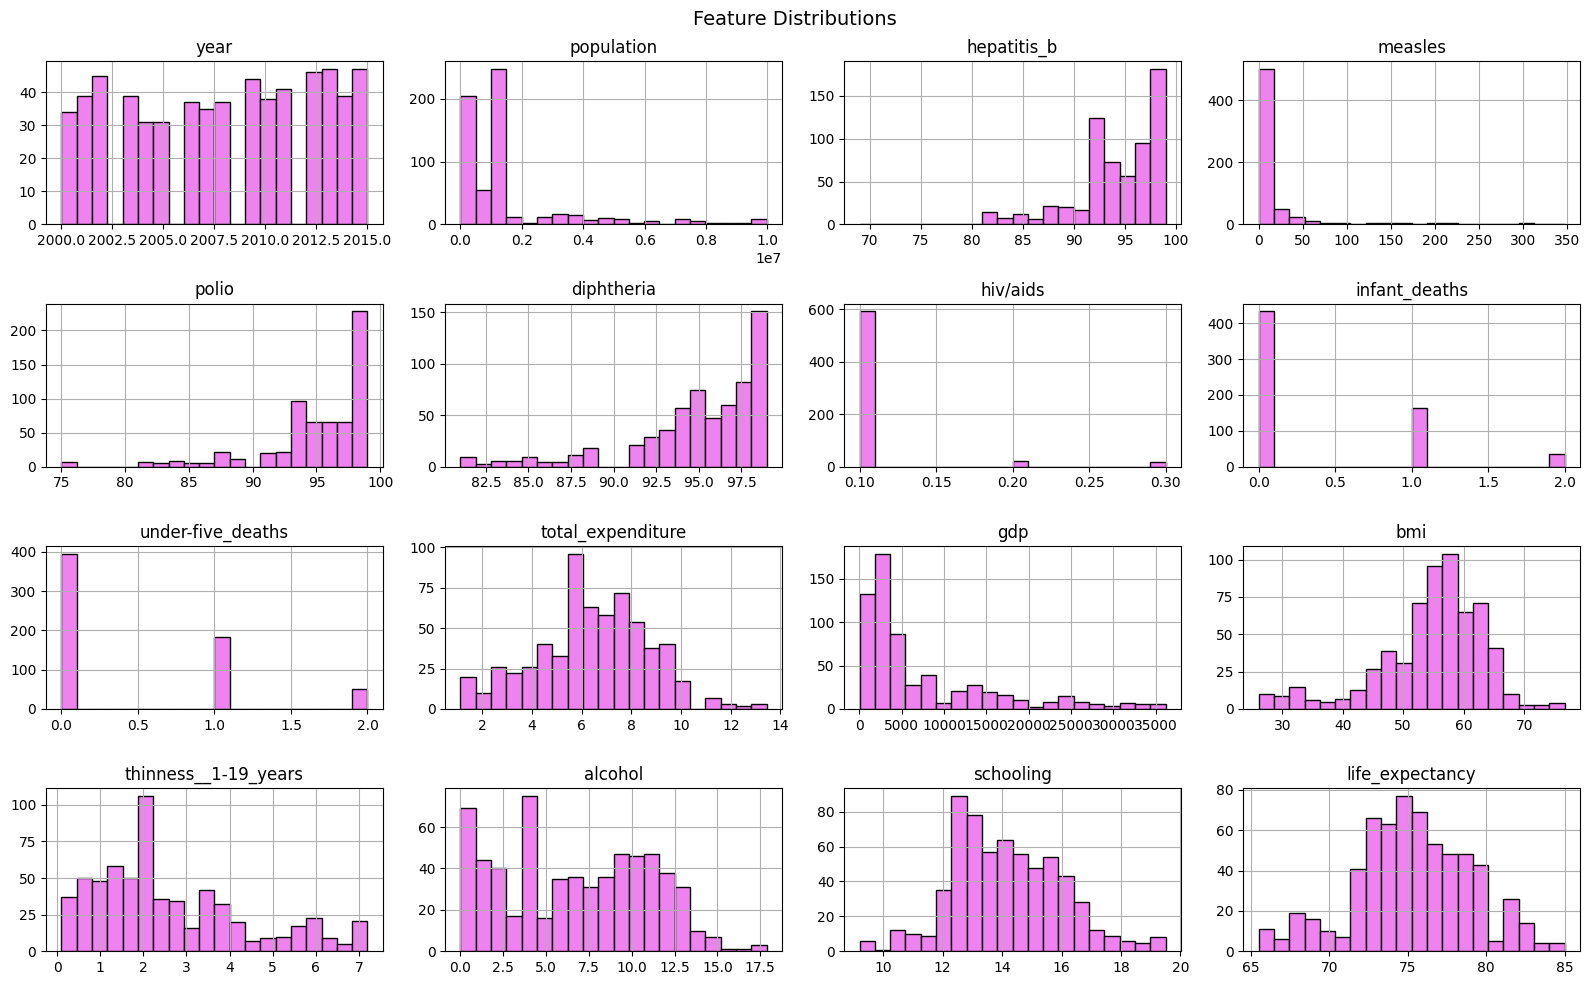

In [29]:
# Distributions
dataframe[num_cols].hist(figsize=(16, 10), bins=20, edgecolor="black", color="violet")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout(); plt.show()

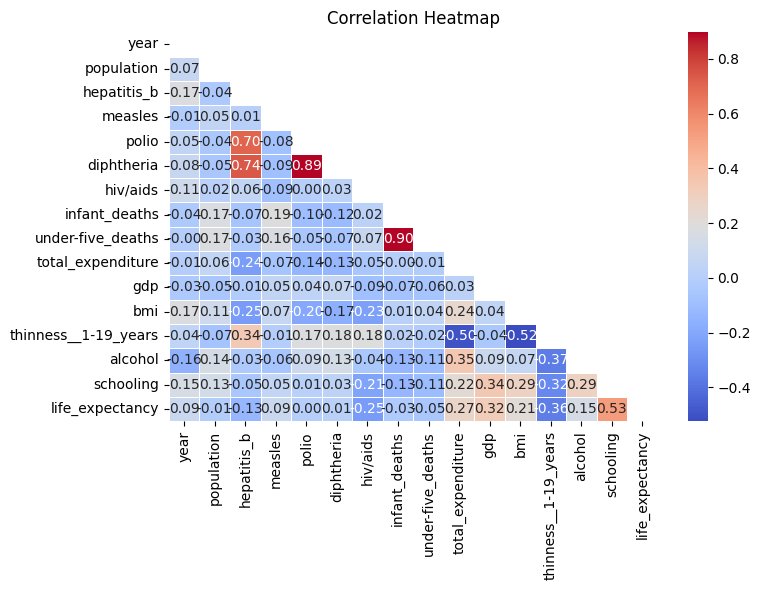

In [30]:
# Correlation shows relationships between all features
corr = dataframe[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=np.triu(np.ones_like(corr, dtype=bool)), linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

In [31]:
# Outcome1: Regression(Predictive Modeling/Analysis)

#import required packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [32]:
dataframe = pd.read_csv("life_expectancy.csv")
dataframe.columns = dataframe.columns.str.lower().str.replace(" ", "_")
dataframe.drop_duplicates(inplace=True)
dataframe.fillna(dataframe.median(numeric_only=True), inplace=True)
dataframe["status"] = LabelEncoder().fit_transform(dataframe["status"].str.strip())
dataframe.drop(columns=["country"], inplace=True)

In [33]:
# Split the data in 70:30
X = dataframe.drop(columns=["life_expectancy"])
y = dataframe["life_expectancy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

In [34]:
#Model training and building
models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        "MAE" : round(mean_absolute_error(y_test, pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 3),
        "R2"  : round(r2_score(y_test, pred), 3),
        "pred": pred,
    }

In [35]:
print(f"\n{'Model':<22} {'MAE':>6} {'RMSE':>6} {'R2':>6}")
print("-" * 42)
for name, m in results.items():
    print(f"{name:<22} {m['MAE']:>6} {m['RMSE']:>6} {m['R2']:>6}")


Model                     MAE   RMSE     R2
------------------------------------------
Linear Regression       3.504  4.696   0.76
Random Forest           1.475  2.266  0.944
Gradient Boosting       2.049  2.887  0.909



 Best Model: Random Forest  (R2 = 0.944)


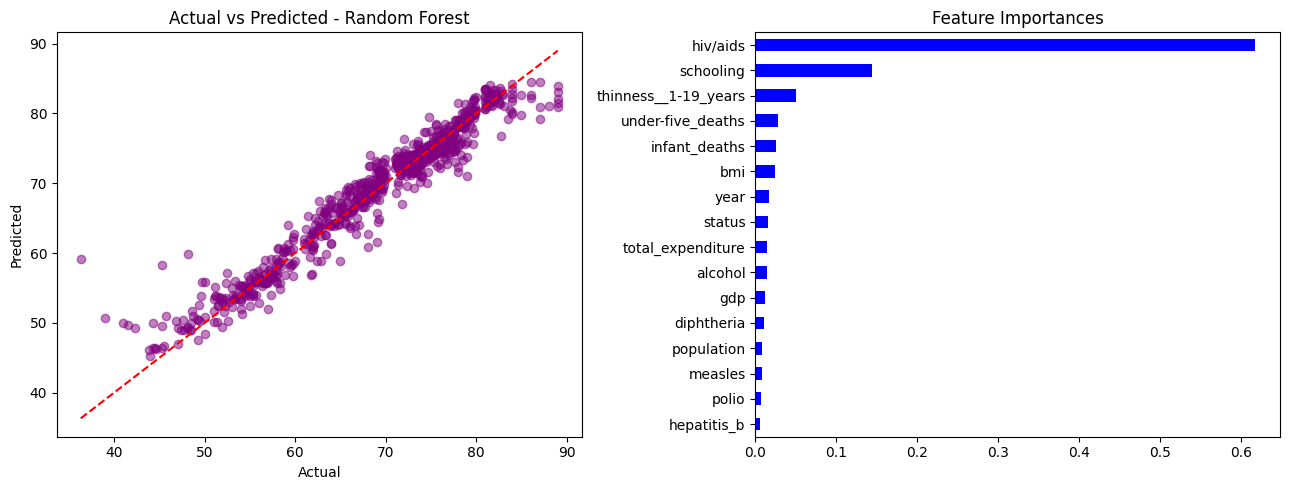

In [36]:
best_name  = max(models, key=lambda n: r2_score(y_test, models[n].predict(X_test)))
best_pred  = models[best_name].predict(X_test)
print(f"\n Best Model: {best_name}  (R2 = {results[best_name]['R2']})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.5, color="Purple")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted - {best_name}")

# Feature Importance
importances = models[best_name].feature_importances_
fi = pd.Series(importances, index=X.columns).sort_values()
fi.plot(kind="barh", ax=axes[1], color="Blue")
axes[1].set_title("Feature Importances")

plt.tight_layout()
plt.show()